In [1]:
!pip install ultralytics
!pip install torch torchvision
!pip install pycocotools
!pip install supervision

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 30.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 251.6/251.6 kB 12.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 6.8 MB/s eta 0:00:00


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
!pip install -q kaggle

In [5]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"richavasudeva","key":"431836916cac4626117dc00e2b6adc40"}'}

In [6]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [7]:
!kaggle datasets download -d hannanguyen24/kitti-object-detection-2d

Dataset URL: https://www.kaggle.com/datasets/hannanguyen24/kitti-object-detection-2d
License(s): unknown
100% 11.5G/11.5G [02:03<00:00, 99.8MB/s]



In [8]:
!unzip -q kitti-object-detection-2d.zip -d /content/kitti

In [9]:
import os

for root, dirs, files in os.walk("/content/kitti"):
    level = root.replace("/content/kitti", "").count(os.sep)
    indent = " " * 4 * level

    print(f"{indent}{os.path.basename(root)}/")

    for f in files[:5]:
        print(" " * 4 * (level + 1) + f)

    if level > 4:
        continue

kitti/
    data.yaml
    Downloads/
        train/
            images/
                002980.png
                004710.png
                001122.png
                005579.png
                000570.png
            labels/
                000849.txt
                003353.txt
                006032.txt
                004428.txt
                001134.txt
        val/
            images/
                007306.png
                007018.png
                007325.png
                007289.png
                007376.png
            labels/
                007330.txt
                007429.txt
                007417.txt
                007097.txt
                007164.txt
        test/
            images/
                002980.png
                004710.png
                001122.png
                005579.png
                000570.png


In [10]:
import os

BASE = "/content/kitti"

for folder in [
    "Downloads/train/images",
    "Downloads/train/labels",
    "Downloads/val/images",
    "Downloads/val/labels"
]:

    path = os.path.join(BASE, folder)

    print("\n", path)

    print("Exists:", os.path.exists(path))

    if os.path.exists(path):
        print("Files:", len(os.listdir(path)))


 /content/kitti/Downloads/train/images
Exists: True
Files: 7001

 /content/kitti/Downloads/train/labels
Exists: True
Files: 7001

 /content/kitti/Downloads/val/images
Exists: True
Files: 480

 /content/kitti/Downloads/val/labels
Exists: True
Files: 480


In [11]:
import yaml

with open("/content/kitti/data.yaml") as f:
    data = yaml.safe_load(f)

print(data)

{'names': ['Car', 'Van', 'Truck', 'Pedestrian', 'Person_sitting', 'Cyclist', 'Tram', 'Misc', "Don't care"], 'nc': 9, 'test': '/kaggle/input/kitti-object-detection-2d/Downloads/test', 'train': '/kaggle/input/kitti-object-detection-2d/Downloads/train', 'val': '/kaggle/input/kitti-object-detection-2d/Downloads/val'}


In [12]:
import os

LBL_DIR = "/content/kitti/Downloads/train/labels"

sample = sorted(os.listdir(LBL_DIR))[0]

print("File:", sample)

with open(os.path.join(LBL_DIR,sample)) as f:

    for i in range(5):
        print(f.readline())

File: 000000.txt
Pedestrian 0.00 0 -0.20 712.40 143.00 810.73 307.92 1.89 0.48 1.20 1.84 1.47 8.41 0.01







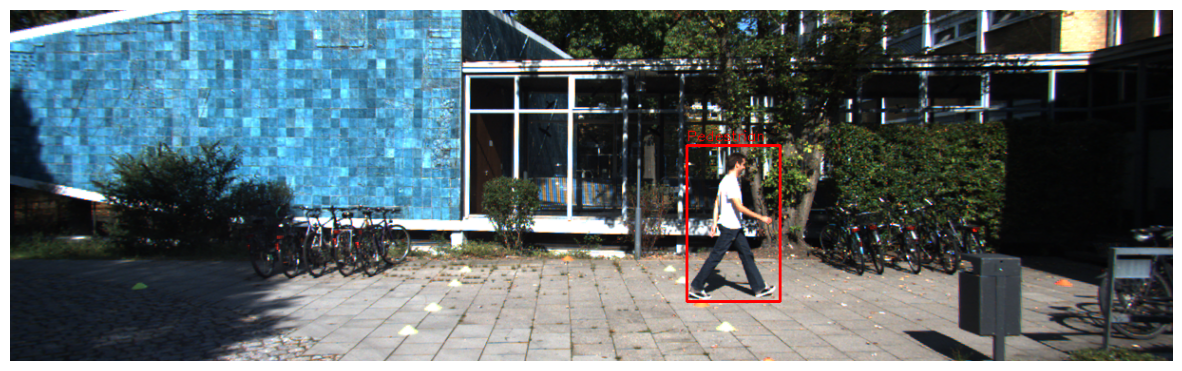

In [13]:
# visulaising bounding boxes

import cv2
import os
import matplotlib.pyplot as plt

IMG_DIR = "/content/kitti/Downloads/train/images"
LBL_DIR = "/content/kitti/Downloads/train/labels"

img_file = "000000.png"

img = cv2.imread(os.path.join(IMG_DIR,img_file))
img = cv2.cvtColor(img,cv2.COLOR_BGR2RGB)

with open(os.path.join(LBL_DIR,"000000.txt")) as f:
    lines = f.readlines()

for line in lines:

    vals = line.strip().split()

    cls_name = vals[0]

    xmin = int(float(vals[4]))
    ymin = int(float(vals[5]))

    xmax = int(float(vals[6]))
    ymax = int(float(vals[7]))

    cv2.rectangle(
        img,
        (xmin,ymin),
        (xmax,ymax),
        (255,0,0),
        2
    )

    cv2.putText(
        img,
        cls_name,
        (xmin,ymin-5),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.5,
        (255,0,0),
        1
    )

plt.figure(figsize=(15,8))
plt.imshow(img)
plt.axis("off")
plt.show()

In [14]:
# converting kitti to yolo format
import os
import cv2

BASE = "/content/kitti/Downloads"
OUT = "/content/kitti_yolo"

os.makedirs(f"{OUT}/train/images", exist_ok=True)
os.makedirs(f"{OUT}/train/labels", exist_ok=True)

os.makedirs(f"{OUT}/val/images", exist_ok=True)
os.makedirs(f"{OUT}/val/labels", exist_ok=True)

CLASS_MAP = {
    "Car":0,
    "Van":1,
    "Truck":2,
    "Pedestrian":3,
    "Person_sitting":4,
    "Cyclist":5,
    "Tram":6,
    "Misc":7
}

for split in ["train","val"]:

    img_dir = f"{BASE}/{split}/images"
    lbl_dir = f"{BASE}/{split}/labels"

    out_img = f"{OUT}/{split}/images"
    out_lbl = f"{OUT}/{split}/labels"

    count = 0

    for img_file in os.listdir(img_dir):

        count += 1

        if count % 500 == 0:
            print(split, count)

        img_path = os.path.join(img_dir,img_file)

        img = cv2.imread(img_path)

        h,w,_ = img.shape

        src_label = os.path.join(
            lbl_dir,
            img_file.replace(".png",".txt")
        )

        dst_label = os.path.join(
            out_lbl,
            img_file.replace(".png",".txt")
        )

        yolo_lines = []

        with open(src_label) as f:

            for line in f:

                vals = line.strip().split()

                cls = vals[0]

                if cls not in CLASS_MAP:
                    continue

                xmin = float(vals[4])
                ymin = float(vals[5])

                xmax = float(vals[6])
                ymax = float(vals[7])

                xc = ((xmin+xmax)/2)/w
                yc = ((ymin+ymax)/2)/h

                bw = (xmax-xmin)/w
                bh = (ymax-ymin)/h

                yolo_lines.append(
                    f"{CLASS_MAP[cls]} {xc} {yc} {bw} {bh}"
                )

        with open(dst_label,"w") as f:
            f.write("\n".join(yolo_lines))

print("Conversion Complete")

train 500
train 1000
train 1500
train 2000
train 2500
train 3000
train 3500
train 4000
train 4500
train 5000
train 5500
train 6000
train 6500
train 7000
Conversion Complete


In [15]:
# veryfing conversion
import os

sample = sorted(
    os.listdir("/content/kitti_yolo/train/labels")
)[0]

print(sample)

with open(
    f"/content/kitti_yolo/train/labels/{sample}"
) as f:
    print(f.read())

000000.txt
3 0.6221936274509804 0.6093513513513513 0.08033496732026148 0.4457297297297298


In [16]:
# creating yolo yaml
import yaml

data = {
    "path": "/content/kitti_yolo",

    "train": "train/images",

    "val": "val/images",

    "names": {
        0:"Car",
        1:"Van",
        2:"Truck",
        3:"Pedestrian",
        4:"Person_sitting",
        5:"Cyclist",
        6:"Tram",
        7:"Misc"
    }
}

with open("/content/kitti_yolo.yaml","w") as f:
    yaml.dump(data,f)

print("YAML Created")

YAML Created


In [17]:
!pip install -q ultralytics

In [18]:
import torch

print(torch.cuda.is_available())

if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))

True
Tesla T4


In [20]:
import os

print("Train Images:", len(os.listdir("/content/kitti_yolo/train/images")))
print("Train Labels:", len(os.listdir("/content/kitti_yolo/train/labels")))

print("Val Images:", len(os.listdir("/content/kitti_yolo/val/images")))
print("Val Labels:", len(os.listdir("/content/kitti_yolo/val/labels")))

Train Images: 0
Train Labels: 7001
Val Images: 0
Val Labels: 480


In [21]:
import shutil
import os

SRC_BASE = "/content/kitti/Downloads"
DST_BASE = "/content/kitti_yolo"

for split in ["train","val"]:

    src_img = f"{SRC_BASE}/{split}/images"
    dst_img = f"{DST_BASE}/{split}/images"

    count = 0

    for file in os.listdir(src_img):

        shutil.copy(
            os.path.join(src_img,file),
            os.path.join(dst_img,file)
        )

        count += 1

        if count % 1000 == 0:
            print(split, count)

print("Image Copy Complete")

train 1000
train 2000
train 3000
train 4000
train 5000
train 6000
train 7000
Image Copy Complete


In [22]:
import os

print("Train Images:", len(os.listdir("/content/kitti_yolo/train/images")))
print("Train Labels:", len(os.listdir("/content/kitti_yolo/train/labels")))

print("Val Images:", len(os.listdir("/content/kitti_yolo/val/images")))
print("Val Labels:", len(os.listdir("/content/kitti_yolo/val/labels")))

Train Images: 7001
Train Labels: 7001
Val Images: 480
Val Labels: 480


In [23]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

results = model.train(
    data="/content/kitti_yolo.yaml",
    epochs=3,
    imgsz=640,
    batch=16,
    device=0,
    workers=2,
    project="kitti_project",
    name="yolo_vehicle"
)

Ultralytics 8.4.56 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/kitti_yolo.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=3, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo_vehicle-2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100,

In [24]:
# evaluating yolo
from ultralytics import YOLO

best_model = YOLO(
    "/content/runs/detect/kitti_project/yolo_vehicle-2/weights/best.pt"
)

metrics = best_model.val()

print("mAP50-95 =", metrics.box.map)
print("mAP50 =", metrics.box.map50)
print("Precision =", metrics.box.mp)
print("Recall =", metrics.box.mr)

Ultralytics 8.4.56 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,007,208 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2943.6±745.6 MB/s, size: 862.8 KB)
val: Scanning /content/kitti_yolo/val/labels.cache... 480 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 480/480 111.8Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 30/30 3.2it/s 9.3s
                   all        480       2476      0.549      0.533      0.568      0.346
                   Car        420       1825      0.839      0.822      0.893      0.631
                   Van        140        173      0.466      0.618      0.602      0.414
                 Truck         52         57      0.467      0.789      0.694      0.525
            Pedestrian        107        224      0.489       0.67      0.618      0.335
        Person_sitting          7         19  

In [25]:
# yolo fps
import os
import cv2
import time

test_dir = "/content/kitti/Downloads/val/images"

images = os.listdir(test_dir)[:100]

start = time.time()

for img_name in images:

    img = cv2.imread(
        os.path.join(test_dir,img_name)
    )

    best_model.predict(
        img,
        verbose=False
    )

end = time.time()

fps = len(images)/(end-start)

print("YOLO FPS =",fps)

YOLO FPS = 43.85068512513581


In [26]:
# FASTER RCNN
import torch
import torchvision

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model_frcnn = torchvision.models.detection.fasterrcnn_resnet50_fpn(
    weights="DEFAULT"
)

model_frcnn.to(device)

model_frcnn.eval()

print("Faster R-CNN Loaded")

Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth


100%|██████████| 160M/160M [00:01<00:00, 152MB/s]


Faster R-CNN Loaded


In [27]:
# faster rcnn fps
import os
import cv2
import time
from torchvision.transforms import functional as F

test_dir = "/content/kitti/Downloads/val/images"

images = os.listdir(test_dir)[:100]

start = time.time()

for img_name in images:

    img = cv2.imread(
        os.path.join(test_dir,img_name)
    )

    img = cv2.cvtColor(
        img,
        cv2.COLOR_BGR2RGB
    )

    tensor = F.to_tensor(img).to(device)

    with torch.no_grad():
        model_frcnn([tensor])

end = time.time()

fps_frcnn = len(images)/(end-start)

print("Faster RCNN FPS =",fps_frcnn)

Faster RCNN FPS = 10.63509103551148


In [28]:
# faster rcnn mean iou
import os
import cv2
import torch
import numpy as np
from torchvision.transforms import functional as F

def iou(boxA, boxB):

    xA = max(boxA[0], boxB[0])
    yA = max(boxA[1], boxB[1])

    xB = min(boxA[2], boxB[2])
    yB = min(boxA[3], boxB[3])

    interArea = max(0, xB-xA) * max(0, yB-yA)

    boxAArea = (boxA[2]-boxA[0])*(boxA[3]-boxA[1])
    boxBArea = (boxB[2]-boxB[0])*(boxB[3]-boxB[1])

    if boxAArea + boxBArea - interArea == 0:
        return 0

    return interArea/(boxAArea+boxBArea-interArea)

IMG_DIR = "/content/kitti/Downloads/val/images"
LBL_DIR = "/content/kitti/Downloads/val/labels"

ious = []

images = sorted(os.listdir(IMG_DIR))[:50]

for img_name in images:

    img = cv2.imread(
        os.path.join(IMG_DIR,img_name)
    )

    rgb = cv2.cvtColor(img,cv2.COLOR_BGR2RGB)

    tensor = F.to_tensor(rgb).to(device)

    with torch.no_grad():
        pred = model_frcnn([tensor])[0]

    pred_boxes = pred["boxes"].cpu().numpy()

    gt_boxes = []

    label_file = os.path.join(
        LBL_DIR,
        img_name.replace(".png",".txt")
    )

    with open(label_file) as f:

        for line in f:

            vals = line.strip().split()

            gt_boxes.append([
                float(vals[4]),
                float(vals[5]),
                float(vals[6]),
                float(vals[7])
            ])

    for gt in gt_boxes:

        best = 0

        for pb in pred_boxes:

            best = max(best,iou(gt,pb))

        ious.append(best)

print("Mean IoU =",np.mean(ious))

Mean IoU = 0.6659687043614175


In [29]:
import os
import cv2
import torch
from torchvision.transforms import functional as F

def iou(boxA, boxB):

    xA = max(boxA[0], boxB[0])
    yA = max(boxA[1], boxB[1])

    xB = min(boxA[2], boxB[2])
    yB = min(boxA[3], boxB[3])

    inter = max(0, xB-xA) * max(0, yB-yA)

    areaA = (boxA[2]-boxA[0]) * (boxA[3]-boxA[1])
    areaB = (boxB[2]-boxB[0]) * (boxB[3]-boxB[1])

    union = areaA + areaB - inter

    if union == 0:
        return 0

    return inter / union


IMG_DIR = "/content/kitti/Downloads/val/images"
LBL_DIR = "/content/kitti/Downloads/val/labels"

TP = 0
FP = 0
FN = 0

images = sorted(os.listdir(IMG_DIR))[:100]

for img_name in images:

    img = cv2.imread(os.path.join(IMG_DIR, img_name))

    rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    tensor = F.to_tensor(rgb).to(device)

    with torch.no_grad():
        preds = model_frcnn([tensor])[0]

    pred_boxes = preds["boxes"].cpu().numpy()

    gt_boxes = []

    label_file = os.path.join(
        LBL_DIR,
        img_name.replace(".png",".txt")
    )

    with open(label_file) as f:

        for line in f:

            vals = line.strip().split()

            gt_boxes.append([
                float(vals[4]),
                float(vals[5]),
                float(vals[6]),
                float(vals[7])
            ])

    matched_gt = set()

    for pred_box in pred_boxes:

        best_iou = 0
        best_gt = -1

        for idx, gt_box in enumerate(gt_boxes):

            score = iou(pred_box, gt_box)

            if score > best_iou:
                best_iou = score
                best_gt = idx

        if best_iou >= 0.5:
            TP += 1
            matched_gt.add(best_gt)
        else:
            FP += 1

    FN += len(gt_boxes) - len(matched_gt)

precision = TP / (TP + FP + 1e-6)
recall = TP / (TP + FN + 1e-6)

print("TP =", TP)
print("FP =", FP)
print("FN =", FN)

print("Precision =", precision)
print("Recall =", recall)

TP = 709
FP = 3224
FN = 165
Precision = 0.1802695143197891
Recall = 0.8112128137171478


In [30]:
import pandas as pd

results = {
    "Metric": [
        "mAP@0.5",
        "mAP@0.5:0.95",
        "IoU",
        "Precision",
        "Recall",
        "FPS"
    ],

    "YOLOv8": [
        0.568,
        0.346,
        None,      # Not computed
        0.549,
        0.533,
        43.85
    ],

    "Faster R-CNN": [
        None,      # Not computed
        None,      # Not computed
        0.666,
        0.180,
        0.811,
        10.64
    ]
}

df = pd.DataFrame(results)

print("="*60)
print("YOLO vs Faster R-CNN Comparison")
print("="*60)

print(df)

print("\n")
print("="*60)
print("TRADE-OFF ANALYSIS")
print("="*60)

if 43.85 > 10.64:
    print("\n✓ YOLO is significantly faster than Faster R-CNN.")
    print(f"  YOLO FPS = 43.85")
    print(f"  Faster R-CNN FPS = 10.64")

print("\n✓ Localization Accuracy")

print(f"  Faster R-CNN Mean IoU = 0.666")

print("  Higher IoU indicates more accurate bounding-box localization.")

print("\n✓ Recall Comparison")

print(f"  YOLO Recall = 0.533")
print(f"  Faster R-CNN Recall = 0.811")

print("  Faster R-CNN detects a larger proportion of objects.")

print("\n✓ Precision Comparison")

print(f"  YOLO Precision = 0.549")
print(f"  Faster R-CNN Precision = 0.180")

print("  YOLO produces fewer false positives.")

print("\nFINAL CONCLUSION")

print("""
For smart-city traffic surveillance, YOLO is more suitable
for real-time vehicle monitoring because it achieves
high processing speed (43.85 FPS) while maintaining
reasonable detection accuracy.

Faster R-CNN provides better localization accuracy
(IoU = 0.666) and higher recall (0.811), meaning it
detects more objects and produces tighter bounding boxes.
However, it is significantly slower (10.64 FPS).

Therefore:

• YOLO → Best for real-time traffic monitoring.
• Faster R-CNN → Best for high-accuracy analysis.
• Speed–Accuracy Trade-off:
  YOLO sacrifices some localization accuracy to gain
  much higher speed, whereas Faster R-CNN sacrifices
  speed to achieve better object localization.
""")

YOLO vs Faster R-CNN Comparison
         Metric  YOLOv8  Faster R-CNN
0       mAP@0.5   0.568           NaN
1  mAP@0.5:0.95   0.346           NaN
2           IoU     NaN         0.666
3     Precision   0.549         0.180
4        Recall   0.533         0.811
5           FPS  43.850        10.640


TRADE-OFF ANALYSIS

✓ YOLO is significantly faster than Faster R-CNN.
  YOLO FPS = 43.85
  Faster R-CNN FPS = 10.64

✓ Localization Accuracy
  Faster R-CNN Mean IoU = 0.666
  Higher IoU indicates more accurate bounding-box localization.

✓ Recall Comparison
  YOLO Recall = 0.533
  Faster R-CNN Recall = 0.811
  Faster R-CNN detects a larger proportion of objects.

✓ Precision Comparison
  YOLO Precision = 0.549
  Faster R-CNN Precision = 0.180
  YOLO produces fewer false positives.

FINAL CONCLUSION

For smart-city traffic surveillance, YOLO is more suitable
for real-time vehicle monitoring because it achieves
high processing speed (43.85 FPS) while maintaining
reasonable detection accuracy.
